### **Lunar Lander DQN KERAS using Clases**

This is a naive version of the Lunar Lander DQN algorithm using an Agent Class<br>
<br>
In this version the agent has been created as a class making the code more compact <br>
This DQN Class can be used with other environments <br>
 <br>
Try to make it faster by doing some hyperparameter optimization  <br>
Try to explore less. Does it accelerates convergence?  <br>
Increasing the ```ROLLING_WINDOW``` value will gnerate slower agent convergence but the Agent behavior will be more consistent <br>

An issue you may find is a lander that hovers forever. This happens because it has been programmed with infinite fuel. You can see it in this execution in the lines that are marked as ```Terminated=False```. This confuses the training because it does not reach the objective or termination. Without modifying the environment, there are a couple of things that can be done to ameliorate this behavior <br>

1. **Limit number of steps** In this case we are limiting the number of steps to 1200, if you don't limit it sometimes it goes up to thousands of steps, and this is a waste of time
2. **Increase gravity** The default gravity in this environment is -10.0, you can increase it up to -12.0, increasing it you'll have a faster descent and hovering becomes more difficult ```env = gym.make("LunarLander-v3", gravity=11.0)```

In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
os.environ["KERAS_BACKEND"] = "torch"

import random
import gymnasium as gym
import time
import numpy as np
from collections import deque
from keras.models import Sequential, Model
from keras.layers import Dense, Input
from keras.optimizers import Adam
import matplotlib.pyplot as plt
from PIL import Image
import time

import sys
sys.stderr = open('err.txt', 'w')

In [3]:
import torch
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version (built):", torch.version.cuda)
print("Device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")
        print(f"    Compute capability: {torch.cuda.get_device_capability(i)}")
        print(f"    Memory: {torch.cuda.get_device_properties(i).total_memory / 1e9:.1f} GB")

    # Quick sanity check: actually run something on the GPU
    x = torch.randn(1000, 1000, device="cuda")
    y = x @ x
    print("Matmul on GPU OK, result shape:", y.shape)
else:
    print("No GPU visible to PyTorch.")

PyTorch version: 2.11.0+cu130
CUDA available: True
CUDA version (built): 13.0
Device count: 1
  GPU 0: NVIDIA GB10
    Compute capability: (12, 1)
    Memory: 130.6 GB
Matmul on GPU OK, result shape: torch.Size([1000, 1000])


#### **Hyperparameters**

In [4]:

MAX_EPISODES = 2000
ROLLING_WINDOW = 40
MEMORY_SIZE = 100000
MAX_STEPS = 1200

gamma = 0.99                         # discount rate
epsilon = 1.0                        # exploration rate
epsilon_min = 0.01
epsilon_decay = 0.99
learning_rate = 0.0001
batch_size = 64
solved_threshold = 200

verb = 0                             # to see traces (verbosity)

In [5]:
# Environment setup
env = gym.make('LunarLander-v3')
state_size = env.observation_space.shape[0]
action_size = env.action_space.n

In [6]:
class Agent_DQN():
    def __init__(self, states, actions, alpha, gamma, epsilon):
        self.nS = states
        self.nA = actions
        self.replay_buffer = deque([], maxlen=MEMORY_SIZE)
        self.alpha = alpha
        self.gamma = gamma
        #Explore/Exploit
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.model = self.build_NN()
        self.loss = []

    def build_NN(self):
        inputs = Input(shape=(state_size,), name="state_input")
        x = Dense(128, activation='relu', name="dense_1")(inputs)
        x = Dense(64, activation='relu', name="dense_2")(x)
        x = Dense(32, activation='relu', name="dense_3")(x)
        outputs = Dense(action_size, activation='linear', name="output_layer")(x)
        model = Model(inputs=inputs, outputs=outputs, name="Q_Network")
        model.compile(loss='mse', optimizer=Adam(learning_rate=learning_rate))
        model.summary()
        return model

    def action(self, state):
        action_vals = self.model.predict(state, verbose=0) 
        return np.argmax(action_vals[0])
    
    def random_action(self):
        return random.randrange(self.nA) #Explore
    
    def sample_experiences(self, batch_size):
        indices = np.random.choice(len(self.replay_buffer), batch_size, replace=False)
        batch = [self.replay_buffer[i] for i in indices]
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            np.vstack(states),
            np.array(actions),
            np.array(rewards),
            np.vstack(next_states),
            np.array(dones, dtype=np.float32)
            )
    def store_experience(self, state, action, reward, next_state, done):             # memorize
        self.replay_buffer.append((state, action, reward, next_state, done))
    
    def experience_replay(self, batch_size, epsilon):
        if len(self.replay_buffer) < batch_size:
            return
        minibatch = random.sample(self.replay_buffer, batch_size)
        states, actions, rewards, next_states, dones = self.sample_experiences(batch_size)

        target_qs = self.model.predict(states, verbose=verb)
        next_qs   = self.model.predict(next_states, verbose=verb)

        # Update target Q-values using standard Bellmanlike equation 
        target_qs[np.arange(batch_size), actions] = rewards + gamma * np.max(next_qs, axis=1) * (1 - dones)

        # Train the model on the Q-values
        self.model.fit(states, target_qs, epochs=1, verbose=0)
        return

In [7]:
# Support function
def select_action_greedy(state, agent_DQN):                                    
    if np.random.rand() <= epsilon:
        return agent_DQN.random_action()
    return agent_DQN.action(state) 

#### **Support Functions**

In [8]:
env = gym.make('LunarLander-v3')
state_size = int(env.observation_space.shape[0])
action_size = int(env.action_space.n)

agent = Agent_DQN(state_size, action_size, learning_rate, gamma, epsilon)

Model: "Q_Network"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ state_input (InputLayer)        │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,620 (45.39 KB)

 Trainable params: 11,620 (45.39 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
rewards_per_episode= []
start_time = time.time()

done = False
rolling_avg = 0
rolling_avg_rewards = []



for e in range(MAX_EPISODES):                           # Should be While True, however we limit number of eps
    state, _ = env.reset()
    state = np.reshape(state, [1, state_size])
    total_reward = 0
    
    for step in range(MAX_STEPS):
            
        action = select_action_greedy(state, agent)
        next_state, reward, done, truncated , _ = env.step(action)
                    
        next_state = np.reshape(next_state, [1, state_size])
        agent.store_experience(state, action, reward, next_state, done)
        state = next_state
        total_reward = total_reward + reward
        if done:
            break
            
        
        agent.experience_replay(batch_size, epsilon)
            
    epsilon = max(epsilon_min, epsilon * epsilon_decay)            # decay epsilon
    
    rewards_per_episode.append(total_reward)
    rolling_avg = np.mean(rewards_per_episode[-ROLLING_WINDOW:])   # append rewards
    rolling_avg_rewards.append(rolling_avg)
    print(f"Episode: {e+1:3}/{MAX_EPISODES}, Reward: {total_reward:+7.2f}, "
          f"Epsilon: {epsilon:.2f}, Rolling Avg: {rolling_avg:7.2f}, Steps: {step:4} Terminated: {done} ")

            
    # Check if environment is solved
    if rolling_avg >= solved_threshold:
        print(f"Environment solved in {e+1} episodes!")
#            model.save("lunarlander_ddqn_model1.keras")
        break

end_time = time.time()
print(f"Training completed in {(end_time - start_time)/60:.2f} minutes")

Episode:   1/2000, Reward: -127.07, Epsilon: 0.99, Rolling Avg: -127.07, Steps:  112 Terminated: True 
Episode:   2/2000, Reward: -206.41, Epsilon: 0.98, Rolling Avg: -166.74, Steps:   88 Terminated: True 
Episode:   3/2000, Reward: -102.98, Epsilon: 0.97, Rolling Avg: -145.49, Steps:   76 Terminated: True 
Episode:   4/2000, Reward: -133.88, Epsilon: 0.96, Rolling Avg: -142.59, Steps:  104 Terminated: True 
Episode:   5/2000, Reward: -349.22, Epsilon: 0.95, Rolling Avg: -183.91, Steps:   85 Terminated: True 
Episode:   6/2000, Reward:  -97.91, Epsilon: 0.94, Rolling Avg: -169.58, Steps:   59 Terminated: True 
Episode:   7/2000, Reward: -165.50, Epsilon: 0.93, Rolling Avg: -169.00, Steps:   92 Terminated: True 
Episode:   8/2000, Reward: -537.58, Epsilon: 0.92, Rolling Avg: -215.07, Steps:  113 Terminated: True 
Episode:   9/2000, Reward:  -24.63, Epsilon: 0.91, Rolling Avg: -193.91, Steps:  107 Terminated: True 
Episode:  10/2000, Reward:  -71.57, Epsilon: 0.90, Rolling Avg: -181.68, 

#### **Learning Plot and Episode Rewards**

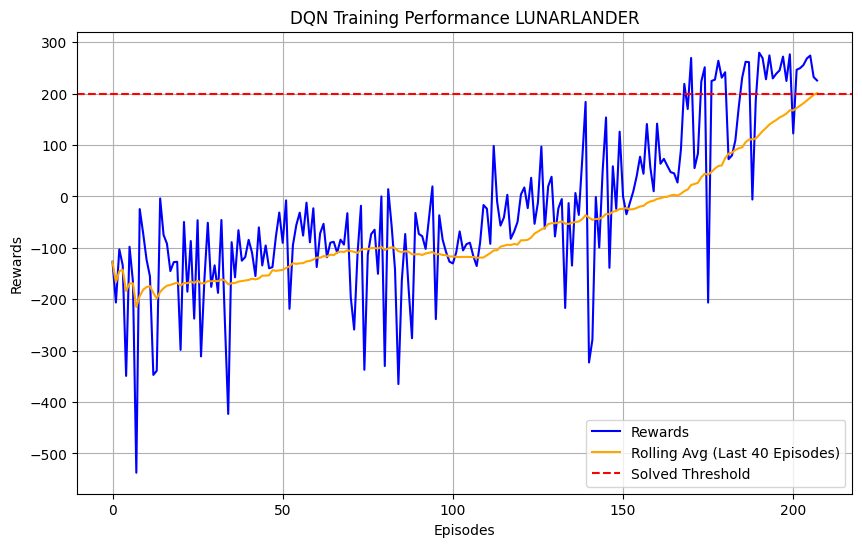

In [10]:
# Plot rewards with rolling average

plt.figure(figsize=(10, 6))
plt.plot(rewards_per_episode, label='Rewards', color='blue')
plt.plot(rolling_avg_rewards, label='Rolling Avg (Last '+str(ROLLING_WINDOW) +' Episodes)', color='orange')
plt.axhline(y=solved_threshold, color='red', linestyle='--', label='Solved Threshold')
plt.title('DQN Training Performance LUNARLANDER')
plt.xlabel('Episodes')
plt.ylabel('Rewards')
plt.legend()
plt.grid()
plt.show()

#### **Simulation - Testing 10 episodes with the DQN Network**

In [11]:
# Testing for 10 episodes
start_time = time.time()

for e_test in range(10):  # Run 10 test episodes
    state, _ = env.reset()
    state = np.reshape(state, [1, state_size])
    total_reward = 0
    
    steps = 0
    while True:
        # Use the trained model for testing
        action = agent.action(state)  # Predict action values


        next_state, reward, done, truncated, _ = env.step(action)
        next_state = np.reshape(next_state, [1, state_size])
        total_reward += reward
        state = next_state
        steps = steps + 1
        if done or truncated:
            print(f"Test Episode: {e_test + 1:2}/10, Reward: {total_reward:.2f}, Steps: {steps:3}")
            break

end_time = time.time()
testing_duration = (end_time - start_time) / 60  # Convert to minutes
print(f"Testing completed in {testing_duration:.2f} minutes")

Test Episode:  1/10, Reward: 166.61, Steps: 1000
Test Episode:  2/10, Reward: 144.44, Steps: 1000
Test Episode:  3/10, Reward: 122.37, Steps: 1000
Test Episode:  4/10, Reward: 209.38, Steps: 334
Test Episode:  5/10, Reward: 257.70, Steps: 443
Test Episode:  6/10, Reward: 266.92, Steps: 238
Test Episode:  7/10, Reward: 247.71, Steps: 463
Test Episode:  8/10, Reward: 274.09, Steps: 268
Test Episode:  9/10, Reward: 270.35, Steps: 264
Test Episode: 10/10, Reward: 227.40, Steps: 247
Testing completed in 0.14 minutes


#### **Rendering 1 episode**

In [12]:
# Test the trained agent with video rendering
# This code is useful if you are using colab otherwise use render_mode='human'
env = gym.make(('LunarLander-v3'), render_mode='rgb_array')  # Enable RGB rendering
frames = []  # Store frames for visualization

# Render a single test episode
state, _ = env.reset()
state = np.reshape(state, [1, state_size])
tot_rewards = 0

while True:
    # Use the trained model for action
    action = agent.action(state)            # Predict action value

    next_state, reward, done, truncated, _ = env.step(action)
    frames.append(env.render())                  # Save frame for rendering later
    next_state = np.reshape(next_state, [1, state_size])
    tot_rewards += reward
    state = next_state

    if done or truncated:
        print(f"Rendered Test Episode Reward: {tot_rewards:.2f}")
        break

env.close()

# Save the rendered episode as a GIF
def save_frames_as_gif(frames, path='./', filename='LUNARLANDER_Agent_DQN.gif'):
    images = [Image.fromarray(frame) for frame in frames]
    gif_path = os.path.join(path, filename)
    images[0].save(gif_path, save_all=True, append_images=images[1:], duration=50, loop=0)
    print(f"Saved GIF to: {gif_path}")

save_frames_as_gif(frames, filename='LUNARLANDER_Agent_DQN.gif')


Rendered Test Episode Reward: 279.70
Saved GIF to: ./LUNARLANDER_Agent_DQN.gif


In [13]:
import session_info
session_info.show(html=False)

-----
PIL                 12.1.0
gymnasium           1.2.2
keras               3.14.1
matplotlib          3.10.8
numpy               2.4.2
session_info        v1.0.1
torch               2.11.0+cu130
-----
IPython             9.10.0
jupyter_client      8.8.0
jupyter_core        5.9.1
-----
Python 3.12.3 (main, Mar 23 2026, 19:04:32) [GCC 13.3.0]
Linux-6.17.0-1014-nvidia-aarch64-with-glibc2.39
-----
Session information updated at 2026-05-13 20:22
